<a href="https://colab.research.google.com/github/HEK-Research/ddi-prediction/blob/master/percent_composition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt

import pandas as pd

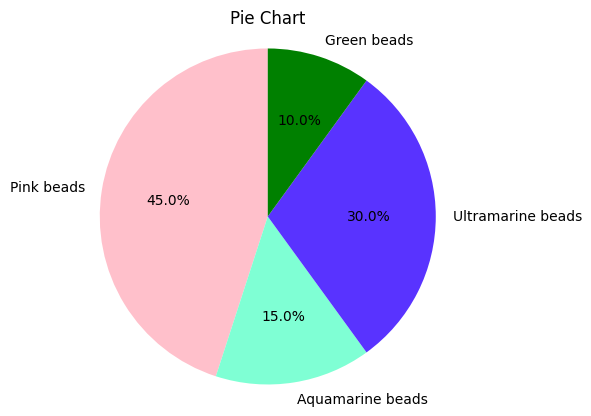

In [ ]:
# Data for the pie chart
sizes = [45, 15, 30, 10]
labels = ['Pink beads', 'Aquamarine beads', 'Ultramarine beads', 'Green beads']
colors = ['pink', 'aquamarine', '#5933ff', 'green']

# Create the pie chart
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

# Add a title
plt.title("Pie Chart")

# Show the plot
plt.show()

Compound    N%    O%  Total Mass
      NO 46.68 53.32       30.01
     NO2 30.45 69.55       46.01
     N2O 63.65 36.35       44.01
    N2O3 36.85 63.15       76.01
    N2O4 30.45 69.55       92.01
    N2O5 25.94 74.06      108.01

Displaying pie charts for each compound...


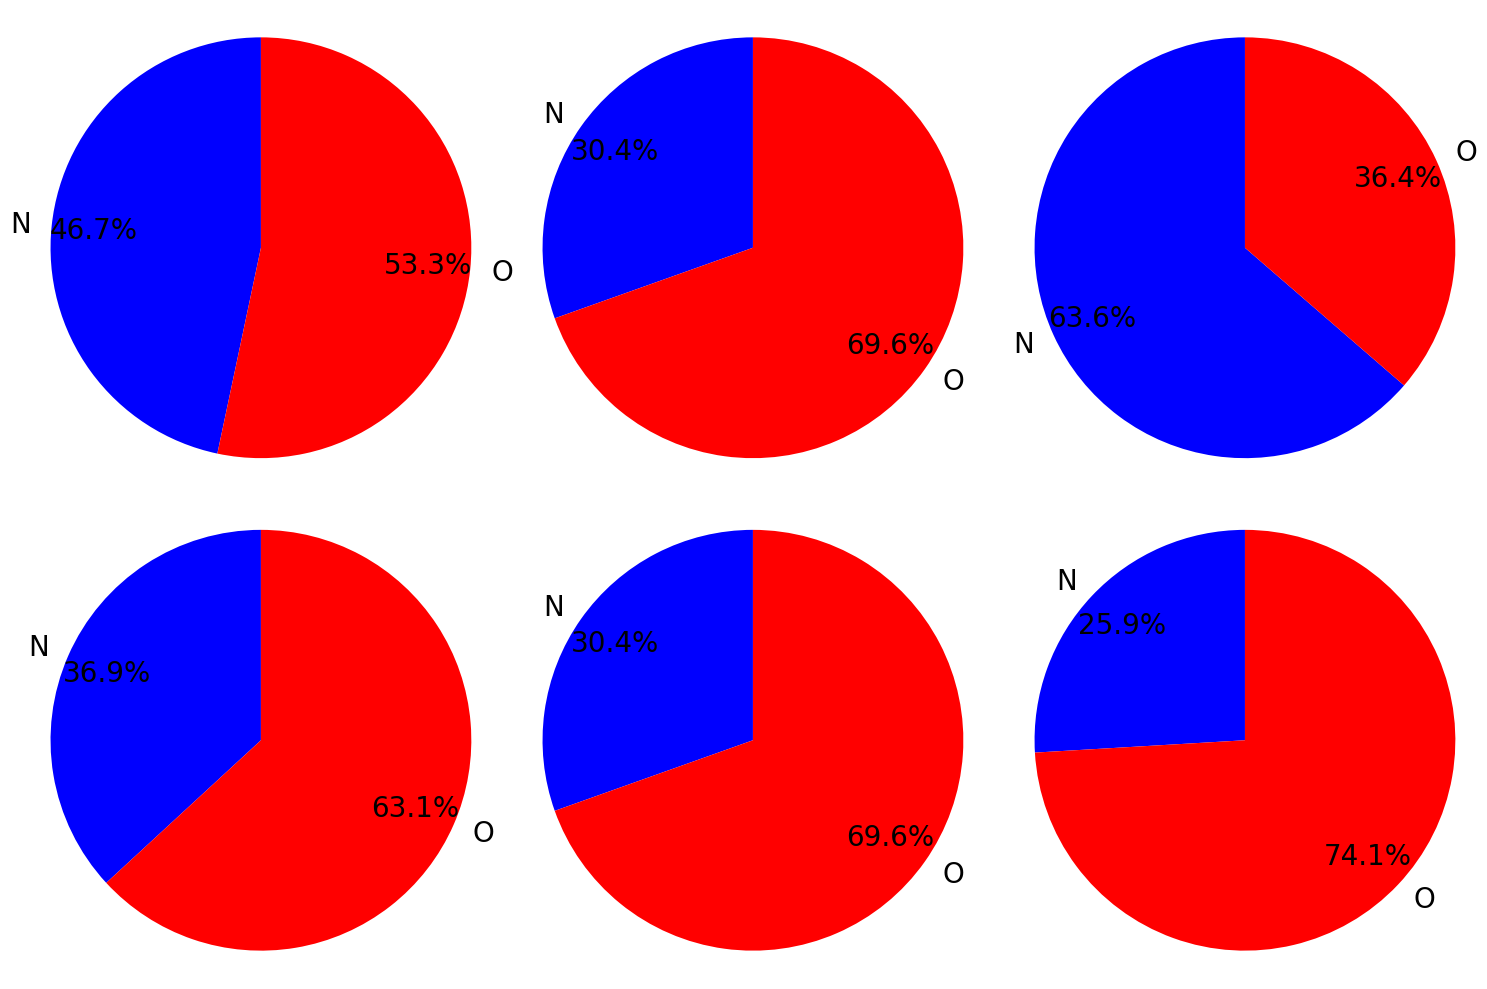

In [ ]:


def calculate_mass_percentage(formula):
    masses = {'N': 14.0067, 'O': 15.9994}
    elements = {}
    for i, char in enumerate(formula):
        if char.isalpha():
            if i+1 < len(formula) and formula[i+1].isdigit():
                elements[char] = int(formula[i+1])
            else:
                elements[char] = elements.get(char, 0) + 1

    total_mass = sum(masses[elem] * count for elem, count in elements.items())
    element_masses = {elem: masses[elem] * count for elem, count in elements.items()}
    percentages = {elem: (mass / total_mass) * 100 for elem, mass in element_masses.items()}

    return percentages, total_mass

def create_pie_chart(ax, compound, percentages):
    labels = list(percentages.keys())
    sizes = list(percentages.values())
    colors = ['blue', 'red']  # Blue for Nitrogen, Orange for Oxygen

    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
           textprops = {'fontsize':20}, labeldistance=1.1, pctdistance=0.8)
    ax.axis('equal')
    #ax.set_title(f"Composition of {compound}", fontsize=16, fontweight='bold')

compounds = ['NO', 'NO2', 'N2O', 'N2O3', 'N2O4', 'N2O5']

results = []
for compound in compounds:
    percentages, total_mass = calculate_mass_percentage(compound)
    results.append({
        'Compound': compound,
        'N%': percentages.get('N', 0),
        'O%': percentages.get('O', 0),
        'Total Mass': total_mass
    })

df = pd.DataFrame(results)
pd.set_option('display.float_format', '{:.2f}'.format)
print(df.to_string(index=False))

print("\nDisplaying pie charts for each compound...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # flatten the 2x3 array to a 1D array

for i, compound in enumerate(compounds):
    percentages, _ = calculate_mass_percentage(compound)
    create_pie_chart(axes[i], compound, percentages)

plt.tight_layout()
plt.show()